In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


# Data Exploration 
## Loaded customer, loan, and region datasets to begin structured exploratory analysis.

In [7]:
cust=pd.read_csv(r"C:\Users\Shreya\OneDrive\Desktop\WsCubeTech\Data Analytics Mentorship Program\CAPSTONE-PROJECT\Goldman Sachs\customer.csv")
loan=pd.read_csv(r"C:\Users\Shreya\OneDrive\Desktop\WsCubeTech\Data Analytics Mentorship Program\CAPSTONE-PROJECT\Goldman Sachs\loan.csv")
loan_count_year=pd.read_csv(r"C:\Users\Shreya\OneDrive\Desktop\WsCubeTech\Data Analytics Mentorship Program\CAPSTONE-PROJECT\Goldman Sachs\loan_count_by_year.csv")
loan_purpose=pd.read_csv(r"C:\Users\Shreya\OneDrive\Desktop\WsCubeTech\Data Analytics Mentorship Program\CAPSTONE-PROJECT\Goldman Sachs\loan_purposes.csv")
loan_with_region=pd.read_csv(r"C:\Users\Shreya\OneDrive\Desktop\WsCubeTech\Data Analytics Mentorship Program\CAPSTONE-PROJECT\Goldman Sachs\loan_with_region.csv")
state_region=pd.read_csv(r"C:\Users\Shreya\OneDrive\Desktop\WsCubeTech\Data Analytics Mentorship Program\CAPSTONE-PROJECT\Goldman Sachs\state_region.csv")


## Used .info(),describe(),shape() to understand data types, structure, distributions, and detect missing values.

In [8]:
print(cust.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270299 entries, 0 to 270298
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          270299 non-null  object 
 1   emp_title            246637 non-null  object 
 2   emp_length           251554 non-null  object 
 3   home_ownership       270299 non-null  object 
 4   annual_inc           270299 non-null  float64
 5   annual_inc_joint     18794 non-null   float64
 6   verification_status  270299 non-null  object 
 7   zip_code             270299 non-null  object 
 8   addr_state           270299 non-null  object 
 9   avg_cur_bal          270299 non-null  float64
 10  Tot_cur_bal          270299 non-null  float64
dtypes: float64(4), object(7)
memory usage: 22.7+ MB
None


In [9]:
print(loan.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270299 entries, 0 to 270298
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   loan_id        270299 non-null  int64  
 1   customer_id    270299 non-null  object 
 2   loan_status    270299 non-null  object 
 3   loan_amount    270299 non-null  float64
 4   state          270299 non-null  object 
 5   funded_amount  270299 non-null  float64
 6   term           270299 non-null  object 
 7   int_rate       270299 non-null  float64
 8   installment    270299 non-null  float64
 9   grade          270299 non-null  object 
 10  issue_d        270299 non-null  object 
 11  issue_date     270299 non-null  object 
 12  issue_year     270299 non-null  float64
 13  pymnt_plan     270299 non-null  bool   
 14  type           270299 non-null  object 
 15  purpose        270299 non-null  object 
 16  description    267956 non-null  object 
 17  notes          270299 non-nul

In [10]:
print(loan_with_region.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270299 entries, 0 to 270298
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   loan_id      270299 non-null  int64  
 1   loan_amount  270299 non-null  float64
 2   region       270299 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 6.2+ MB
None


In [16]:
print("Customer dataset Shape",cust.shape)
print("Loan dataset Shape",loan.shape)
print("Loan with Region dataset Shape",loan_with_region.shape)

Customer dataset Shape (270299, 11)
Loan dataset Shape (270299, 18)
Loan with Region dataset Shape (270299, 3)


In [17]:
print(cust.describe())

         annual_inc  annual_inc_joint    avg_cur_bal   Tot_cur_bal
count  2.702990e+05      1.879400e+04  270299.000000  2.702990e+05
mean   7.961800e+04      1.306721e+05   13668.796092  1.446931e+05
std    8.112625e+04      9.295802e+04   16753.975392  1.639825e+05
min    3.400000e+01      1.540000e+04       0.000000  0.000000e+00
25%    4.735250e+04      8.660000e+04    3107.000000  2.948200e+04
50%    6.600000e+04      1.150000e+05    7376.000000  8.047800e+04
75%    9.500000e+04      1.540750e+05   18921.500000  2.165500e+05
max    9.550000e+06      7.874821e+06  623229.000000  9.971659e+06


In [18]:
print(loan.describe())

             loan_id    loan_amount  funded_amount       int_rate  \
count  270299.000000  270299.000000  270299.000000  270299.000000   
mean   135150.000000   15412.829496   15412.829496       0.130765   
std     78028.744543    9459.781419    9459.781419       0.048865   
min         1.000000    1000.000000    1000.000000       0.053100   
25%     67575.500000    8000.000000    8000.000000       0.094300   
50%    135150.000000   13200.000000   13200.000000       0.126100   
75%    202724.500000   20300.000000   20300.000000       0.160100   
max    270299.000000   40000.000000   40000.000000       0.309900   

         installment     issue_year  
count  270299.000000  270299.000000  
mean      453.919176    2016.587242  
std       272.337511       1.837425  
min        29.520000    2012.000000  
25%       256.040010    2015.000000  
50%       383.959990    2017.000000  
75%       605.120000    2018.000000  
max      1719.830000    2019.000000  


## Identified columns with missing values to determine which features require cleaning, imputation, or removal.

In [19]:
print(cust.isnull().sum())

customer_id                 0
emp_title               23662
emp_length              18745
home_ownership              0
annual_inc                  0
annual_inc_joint       251505
verification_status         0
zip_code                    0
addr_state                  0
avg_cur_bal                 0
Tot_cur_bal                 0
dtype: int64


In [20]:
print(loan.isnull().sum())

loan_id             0
customer_id         0
loan_status         0
loan_amount         0
state               0
funded_amount       0
term                0
int_rate            0
installment         0
grade               0
issue_d             0
issue_date          0
issue_year          0
pymnt_plan          0
type                0
purpose             0
description      2343
notes               0
dtype: int64


# Merging the loan and customers table

## Merged loan and customer datasets on customer_id to create a unified modeling dataset for ML analysis.

In [25]:
df=loan.merge(cust,on ="customer_id",how="left")
print(df.shape)

(270299, 28)


## Rechecked dataset shape and null values to ensure merge integrity and confirm data consistency.

In [26]:
df.isnull().sum().sort_values(ascending=False)

annual_inc_joint       251505
emp_title               23662
emp_length              18745
description              2343
loan_id                     0
customer_id                 0
avg_cur_bal                 0
addr_state                  0
zip_code                    0
verification_status         0
annual_inc                  0
home_ownership              0
notes                       0
purpose                     0
type                        0
pymnt_plan                  0
issue_year                  0
issue_date                  0
issue_d                     0
grade                       0
installment                 0
int_rate                    0
term                        0
funded_amount               0
state                       0
loan_amount                 0
loan_status                 0
Tot_cur_bal                 0
dtype: int64

## Dropped high-missing and non-informative columns (annual_inc_joint, description, emp_title) to reduce noise and improve model clarity.

In [28]:
df=df.drop(columns=['annual_inc_joint','emp_title','description'])
print(df.shape)

(270299, 25)


In [29]:
df['emp_length']

0          < 1 year
1          < 1 year
2           5 years
3           8 years
4           3 years
            ...    
270294    10+ years
270295     < 1 year
270296    10+ years
270297      5 years
270298    10+ years
Name: emp_length, Length: 270299, dtype: object

In [ ]:
# Clean emp_length
df["emp_length"] = df["emp_length"].str.replace(" years", "")
df["emp_length"] = df["emp_length"].str.replace(" year", "")
df["emp_length"] = df["emp_length"].str.replace("+", "", regex=False)
df["emp_length"] = df["emp_length"].str.replace("< 1", "0")

# Convert to numeric
df["emp_length"] = pd.to_numeric(df["emp_length"], errors="coerce")


In [34]:
# Check result
df["emp_length"].head()
df["emp_length"].isnull().sum()

18745

## Filled missing employment length values using median imputation to preserve dataset size and avoid bias from extreme values.

In [35]:
# Fill missing with median
median_emp = df["emp_length"].median()
df["emp_length"] = df["emp_length"].fillna(median_emp)

# Verify
df["emp_length"].isnull().sum()

0

## Converted loan term from text format (e.g., "36 months") into numeric duration to make it suitable for machine learning models.

In [36]:
# Clean term column
df["term"] = df["term"].str.replace(" months", "")

# Convert to numeric
df["term"] = pd.to_numeric(df["term"])

# Verify
df["term"].head()
df["term"].dtype

dtype('int64')

In [39]:
loan['int_rate'].dtype

dtype('float64')

## Created a binary target variable (approval_status) where Fully Paid and Current loans are labeled as Approved (1), and all other statuses as Not Approved/Risky (0).

In [40]:
# Create approval target
df["approval_status"] = df["loan_status"].apply(
    lambda x: 1 if x in ["Fully Paid", "Current"] else 0
)

df["approval_status"].value_counts()

approval_status
1    246822
0     23477
Name: count, dtype: int64

## Observed class imbalance in approval_status (≈91% approved, 9% risky), indicating the need to use precision, recall, and F1-score instead of accuracy for evaluation.

In [41]:
df = df.drop(columns=["loan_status"])

## Dropped loan_status to prevent data leakage since approval_status was derived directly from it.

In [42]:
df.dtypes.value_counts() 

object     12
float64     9
int64       3
bool        1
Name: count, dtype: int64

In [43]:
df.select_dtypes(include="object").columns

Index(['customer_id', 'state', 'grade', 'issue_d', 'issue_date', 'type',
       'purpose', 'notes', 'home_ownership', 'verification_status', 'zip_code',
       'addr_state'],
      dtype='object')

## Identified categorical and numerical features to prepare for encoding and model-ready transformation.

In [45]:
df = df.drop(columns=[
    "customer_id",
    "loan_id",
    "issue_d",
    "issue_date",
    "notes",
    "zip_code",
    "addr_state"
])

## Removed identifier columns and non-informative text fields to prevent noise and ensure only predictive features are retained for modeling.

In [46]:
df.select_dtypes(include="object").columns

Index(['state', 'grade', 'type', 'purpose', 'home_ownership',
       'verification_status'],
      dtype='object')

In [47]:
# Create modeling dataset
df_model = df.copy()

# Drop columns not needed for ML
df_model = df_model.drop(columns=[
    "state",
    "type"
])

# Confirm structure
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270299 entries, 0 to 270298
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   loan_amount          270299 non-null  float64
 1   funded_amount        270299 non-null  float64
 2   term                 270299 non-null  int64  
 3   int_rate             270299 non-null  float64
 4   installment          270299 non-null  float64
 5   grade                270299 non-null  object 
 6   issue_year           270299 non-null  float64
 7   pymnt_plan           270299 non-null  bool   
 8   purpose              270299 non-null  object 
 9   emp_length           270299 non-null  float64
 10  home_ownership       270299 non-null  object 
 11  annual_inc           270299 non-null  float64
 12  verification_status  270299 non-null  object 
 13  avg_cur_bal          270299 non-null  float64
 14  Tot_cur_bal          270299 non-null  float64
 15  approval_status  

## Created a dedicated modeling dataset by removing high-cardinality and low-impact features to prepare structured data for machine learning.

In [48]:
# Define target
y = df_model["approval_status"]

# Define features
X = df_model.drop(columns=["approval_status"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (270299, 15)
y shape: (270299,)


## Separated predictor variables (X) and target variable (y) to prepare the dataset for machine learning training.

In [49]:
# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

print("New X shape:", X.shape)
X.head()

New X shape: (270299, 36)


,loan_amount,funded_amount,term,int_rate,installment,issue_year,pymnt_plan,emp_length,annual_inc,avg_cur_bal,...,purpose_small_business,purpose_vacation,purpose_wedding,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified
0,1000.0,1000.0,36,0.2295,38.689999,2013.0,False,0.0,84000.0,3209.0,...,False,False,False,False,False,False,False,True,True,False
1,1200.0,1200.0,36,0.1629,42.369999,2014.0,False,0.0,32600.0,3068.0,...,False,False,False,False,False,False,False,True,False,False
2,1400.0,1400.0,36,0.1114,45.930000,2012.0,False,5.0,37000.0,6351.0,...,False,False,False,True,False,False,False,False,True,False
3,1975.0,1975.0,36,0.1049,64.190002,2014.0,False,8.0,29000.0,2667.0,...,False,False,False,False,False,False,True,False,False,False
4,2000.0,2000.0,36,0.1875,73.059998,2013.0,False,3.0,60000.0,3580.0,...,False,False,False,False,False,False,False,True,False,False


## Applied one-hot encoding to categorical variables to convert them into numeric format while avoiding multicollinearity using drop_first=True.

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

X_train: (216239, 36)
X_test: (54060, 36)
y_train distribution:
 approval_status
1    0.913142
0    0.086858
Name: proportion, dtype: float64
y_test distribution:
 approval_status
1    0.913152
0    0.086848
Name: proportion, dtype: float64


## Split the dataset into training and testing sets using stratified sampling to preserve class distribution and prevent data leakage.

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")

Scaling complete.


## Applied feature scaling using StandardScaler, fitting only on training data to prevent data leakage and ensure stable model training.

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize model
log_model = LogisticRegression(max_iter=1000)

# Train on scaled data
log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[   41  4654]
 [   57 49308]]

Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.01      0.02      4695
           1       0.91      1.00      0.95     49365

    accuracy                           0.91     54060
   macro avg       0.67      0.50      0.49     54060
weighted avg       0.87      0.91      0.87     54060



## Trained a Logistic Regression model as a baseline classifier to predict loan approval and evaluated performance using precision, recall, and F1-score.

In [53]:
log_model_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")

log_model_balanced.fit(X_train_scaled, y_train)

y_pred_bal = log_model_balanced.predict(X_test_scaled)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bal))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bal))

Confusion Matrix:
 [[ 3301  1394]
 [15679 33686]]

Classification Report:
               precision    recall  f1-score   support

           0       0.17      0.70      0.28      4695
           1       0.96      0.68      0.80     49365

    accuracy                           0.68     54060
   macro avg       0.57      0.69      0.54     54060
weighted avg       0.89      0.68      0.75     54060



## Using class_weight="balanced" significantly improved recall for risky loans (from 1% to 70%), demonstrating better minority class detection at the cost of lower overall accuracy.

In [54]:
from sklearn.tree import DecisionTreeClassifier

# Initialize model
tree_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"   
)

# Train
tree_model.fit(X_train, y_train)

# Predict
y_pred_tree = tree_model.predict(X_test)

# Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))

Confusion Matrix:
 [[  844  3851]
 [ 4041 45324]]

Classification Report:
               precision    recall  f1-score   support

           0       0.17      0.18      0.18      4695
           1       0.92      0.92      0.92     49365

    accuracy                           0.85     54060
   macro avg       0.55      0.55      0.55     54060
weighted avg       0.86      0.85      0.86     54060



## Trained a Decision Tree classifier with balanced class weights to capture nonlinear patterns and improve minority class detection.

## Decision Tree improved minority detection compared to baseline Logistic Regression but underperformed compared to the balanced Logistic model in identifying risky loans.

In [55]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Confusion Matrix:
 [[   82  4613]
 [  110 49255]]

Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.02      0.03      4695
           1       0.91      1.00      0.95     49365

    accuracy                           0.91     54060
   macro avg       0.67      0.51      0.49     54060
weighted avg       0.87      0.91      0.87     54060



In [56]:
# Get feature names
feature_names = X_train.columns

# Extract coefficients
coefficients = log_model_balanced.coef_[0]

# Create dataframe
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by impact
coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

coef_df.head(10)

,Feature,Coefficient
5,issue_year,0.635991
0,loan_amount,0.164592
1,funded_amount,0.164592
9,avg_cur_bal,0.076344
7,emp_length,0.040113
29,home_ownership_MORTGAGE,0.031309
10,Tot_cur_bal,0.023274
28,purpose_wedding,0.022768
30,home_ownership_NONE,0.021458
24,purpose_other,0.016411


In [57]:
coef_df.tail(10)

,Feature,Coefficient
34,verification_status_Source Verified,-0.093565
35,verification_status_Verified,-0.104601
6,pymnt_plan,-0.121594
16,grade_G,-0.154007
15,grade_F,-0.264615
11,grade_B,-0.312111
4,installment,-0.363019
14,grade_E,-0.415819
12,grade_C,-0.541899
13,grade_D,-0.547574


## Extracted and analyzed Logistic Regression coefficients to identify key features influencing loan approval decisions.

## Loan grade is the strongest determinant of approval outcomes, with lower grades significantly reducing approval likelihood. Employment stability, mortgage ownership, and recent issuance years positively influence approval probability, while higher installment burdens and weaker grades act as strong rejection signals.

# Loan Default Prediction Model

In [62]:
# Recreate clean merged dataset
df_base = loan.merge(cust, on="customer_id", how="left")

print(df_base.shape)

(270299, 28)


In [63]:
df_default = df_base.copy()

df_default["default_status"] = df_default["loan_status"].apply(
    lambda x: 1 if x in ["Default", "Charged Off"] else 0
)

df_default["default_status"].value_counts()

default_status
0    252436
1     17863
Name: count, dtype: int64

## Recreated the base merged dataset to restore dropped columns and define a new target variable for strict default prediction.

In [64]:
# Drop leakage + unnecessary columns
df_default = df_default.drop(columns=[
    "loan_status",   # leakage
    "customer_id",
    "loan_id",
    "issue_d",
    "issue_date",
    "notes",
    "zip_code",
    "addr_state",
    "annual_inc_joint",
    "emp_title"
])

In [65]:
df_default.info()
df_default.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270299 entries, 0 to 270298
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   loan_amount          270299 non-null  float64
 1   state                270299 non-null  object 
 2   funded_amount        270299 non-null  float64
 3   term                 270299 non-null  object 
 4   int_rate             270299 non-null  float64
 5   installment          270299 non-null  float64
 6   grade                270299 non-null  object 
 7   issue_year           270299 non-null  float64
 8   pymnt_plan           270299 non-null  bool   
 9   type                 270299 non-null  object 
 10  purpose              270299 non-null  object 
 11  description          267956 non-null  object 
 12  emp_length           251554 non-null  object 
 13  home_ownership       270299 non-null  object 
 14  annual_inc           270299 non-null  float64
 15  verification_stat

emp_length             18745
description             2343
loan_amount                0
purpose                    0
Tot_cur_bal                0
avg_cur_bal                0
verification_status        0
annual_inc                 0
home_ownership             0
type                       0
state                      0
pymnt_plan                 0
issue_year                 0
grade                      0
installment                0
int_rate                   0
term                       0
funded_amount              0
default_status             0
dtype: int64

In [66]:
df_default = df_default.drop(columns=[
    "description",
    "state",
    "type"
])

In [67]:
df_default["emp_length"] = df_default["emp_length"].str.replace(" years", "")
df_default["emp_length"] = df_default["emp_length"].str.replace(" year", "")
df_default["emp_length"] = df_default["emp_length"].str.replace("+", "", regex=False)
df_default["emp_length"] = df_default["emp_length"].str.replace("< 1", "0")

df_default["emp_length"] = pd.to_numeric(df_default["emp_length"], errors="coerce")

# Fill nulls with median
df_default["emp_length"] = df_default["emp_length"].fillna(df_default["emp_length"].median())

In [68]:
df_default["term"] = df_default["term"].str.replace(" months", "")
df_default["term"] = pd.to_numeric(df_default["term"])

In [69]:
df_default.isnull().sum()

loan_amount            0
funded_amount          0
term                   0
int_rate               0
installment            0
grade                  0
issue_year             0
pymnt_plan             0
purpose                0
emp_length             0
home_ownership         0
annual_inc             0
verification_status    0
avg_cur_bal            0
Tot_cur_bal            0
default_status         0
dtype: int64

## Cleaned default prediction dataset by removing non-informative features, converting employment length and term to numeric format, and imputing missing values using median strategy.

In [70]:
# ==============================
# 1️⃣ Separate X and y
# ==============================

y_def = df_default["default_status"]
X_def = df_default.drop(columns=["default_status"])


# ==============================
# 2️⃣ One-hot Encode categorical
# ==============================

X_def = pd.get_dummies(X_def, drop_first=True)


# ==============================
# 3️⃣ Train-Test Split
# ==============================

from sklearn.model_selection import train_test_split

X_train_def, X_test_def, y_train_def, y_test_def = train_test_split(
    X_def,
    y_def,
    test_size=0.2,
    random_state=42,
    stratify=y_def
)


# ==============================
# 4️⃣ Scale (for Logistic)
# ==============================

from sklearn.preprocessing import StandardScaler

scaler_def = StandardScaler()

X_train_def_scaled = scaler_def.fit_transform(X_train_def)
X_test_def_scaled = scaler_def.transform(X_test_def)


# ==============================
# 5️⃣ Train Balanced Logistic
# ==============================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_def = LogisticRegression(max_iter=1000, class_weight="balanced")

log_def.fit(X_train_def_scaled, y_train_def)

y_pred_def = log_def.predict(X_test_def_scaled)

print("Confusion Matrix:\n", confusion_matrix(y_test_def, y_pred_def))
print("\nClassification Report:\n", classification_report(y_test_def, y_pred_def))

Confusion Matrix:
 [[35870 14617]
 [  827  2746]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.71      0.82     50487
           1       0.16      0.77      0.26      3573

    accuracy                           0.71     54060
   macro avg       0.57      0.74      0.54     54060
weighted avg       0.92      0.71      0.79     54060



## The balanced Logistic Regression model achieved 77% recall for default cases, effectively identifying most high-risk borrowers, though at the cost of lower precision due to class imbalance.

In [71]:
feature_names_def = X_train_def.columns
coefficients_def = log_def.coef_[0]

coef_def_df = pd.DataFrame({
    "Feature": feature_names_def,
    "Coefficient": coefficients_def
})

coef_def_df = coef_def_df.sort_values(by="Coefficient", ascending=False)

coef_def_df.head(10)

,Feature,Coefficient
13,grade_D,0.708398
12,grade_C,0.666529
14,grade_E,0.547395
11,grade_B,0.371695
15,grade_F,0.360327
4,installment,0.329843
16,grade_G,0.216385
34,verification_status_Source Verified,0.110247
35,verification_status_Verified,0.105536
18,purpose_debt_consolidation,0.099277


In [72]:
coef_def_df.tail(10)

,Feature,Coefficient
29,home_ownership_MORTGAGE,-0.019909
31,home_ownership_OTHER,-0.033903
30,home_ownership_NONE,-0.036618
7,emp_length,-0.041004
6,pymnt_plan,-0.096956
9,avg_cur_bal,-0.154274
1,funded_amount,-0.156014
0,loan_amount,-0.156014
3,int_rate,-0.200422
5,issue_year,-0.959503


## Loan grade emerged as the strongest predictor of default, with lower grades significantly increasing default probability. Higher installment burdens and debt consolidation purposes also elevate risk, while employment stability, stronger financial balances, and recent loan issuance reduce default likelihood

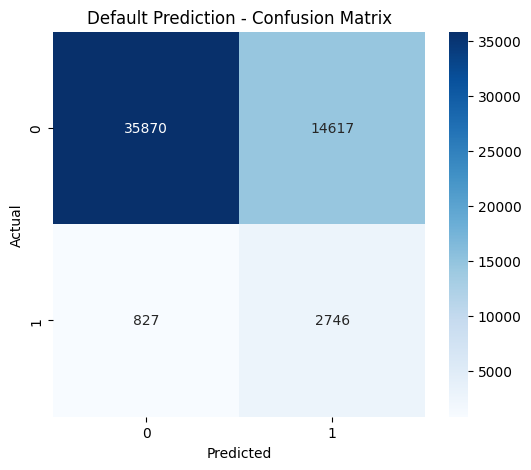

In [73]:
# Confusion matrix
cm_def = confusion_matrix(y_test_def, y_pred_def)

plt.figure(figsize=(6,5))
sns.heatmap(cm_def, annot=True, fmt='d', cmap='Blues')
plt.title("Default Prediction - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Visualized the confusion matrix to clearly evaluate model performance in identifying default and non-default borrowers.

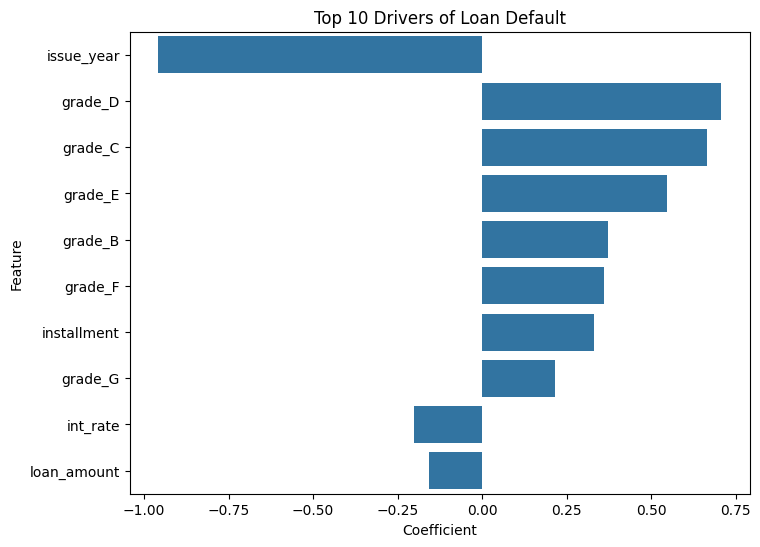

In [74]:
# Get top 10 absolute impact features
coef_def_df["Abs_Coefficient"] = coef_def_df["Coefficient"].abs()
top_features = coef_def_df.sort_values(by="Abs_Coefficient", ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(
    x="Coefficient",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Drivers of Loan Default")
plt.show()

## Plotted the top features influencing loan default based on Logistic Regression coefficients to interpret risk drivers visually.

##  Executive Summary – Loan Risk Modeling

This project developed two supervised machine learning models to support Global FinBank’s risk management strategy:

## 1️ Loan Approval Prediction

Balanced Logistic Regression achieved 70% recall for identifying risky loan applications.

Loan grade emerged as the strongest determinant of approval.

Employment stability, mortgage ownership, and higher financial balances positively influenced approval probability.

## 2️ Loan Default Prediction

Balanced Logistic Regression achieved 77% recall in detecting actual defaults.

Loan grade, installment burden, and debt consolidation purpose significantly increased default risk.

Employment length, higher account balances, and recent loan issuance reduced default probability.

##  Business Impact

The models demonstrate the ability to proactively flag high-risk borrowers while maintaining structured interpretability. These insights can help loan officers refine approval criteria and strengthen risk mitigation strategies.